In [1]:
import kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print(" Dataset Downloaded!")
print("Path:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
 Dataset Downloaded!
Path: /kaggle/input/telco-customer-churn


In [2]:
import os
files = os.listdir(path)
print("Files available:", files)

Files available: ['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All Libraries Imported!")

All Libraries Imported!


In [4]:
df = pd.read_csv(path + '/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(" Dataset Loaded!")
print("Shape:", df.shape)
print(df.head())

 Dataset Loaded!
Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV S

Churn Value Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


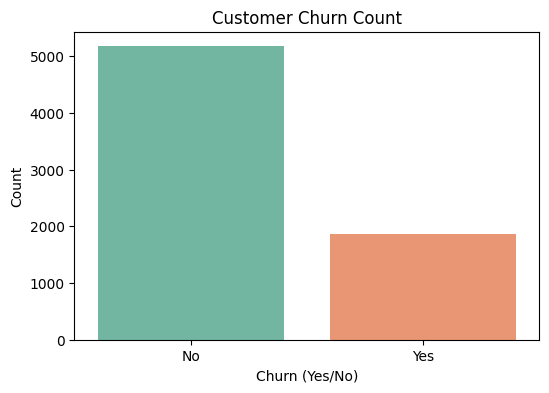


Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [6]:

print("Churn Value Counts:")
print(df['Churn'].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df,
              hue='Churn',
              palette='Set2',
              legend=False)
plt.title("Customer Churn Count")
plt.xlabel("Churn (Yes/No)")
plt.ylabel("Count")
plt.show()
print("\nColumns:", df.columns.tolist())


In [13]:

df = pd.read_csv(path + '/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median())

print("Available columns:")
print(df.columns.tolist())

df = df.drop('customerID', axis=1, errors='ignore')
print("customerID dropped safely!")

print("\nMissing values:")
print(df.isnull().sum())
print("\nData Cleaned!")
print("Shape:", df.shape)

Available columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
customerID dropped safely!

Missing values:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data Cleaned!
Shape: (7043, 20)


In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print("Encoding Done!")
print(df.head())

Encoding Done!
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   
3              1                0               2             0   
4              0                1               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   
1  

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Churn', axis=1)
y = df['Churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data Split Done!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Data Split Done!
Training samples: 5634
Testing samples: 1409


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test))
print(f" Done: {round(lr_acc*100, 2)}%")

print("\nTraining Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
print(f"Done: {round(rf_acc*100, 2)}%")
print("\nTraining Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_acc = accuracy_score(y_test, gb.predict(X_test))
print(f"Done: {round(gb_acc*100, 2)}%")

print("\n======= Model Comparison =======")
print(f"Logistic Regression : {round(lr_acc*100, 2)}%")
print(f"Random Forest       : {round(rf_acc*100, 2)}%")
print(f"Gradient Boosting   : {round(gb_acc*100, 2)}%")
print("=================================")

Training Logistic Regression...
 Done: 79.91%

Training Random Forest...
Done: 79.35%

Training Gradient Boosting...
Done: 80.13%

======= Model Comparison =======
Logistic Regression : 79.91%
Random Forest       : 79.35%
Gradient Boosting   : 80.13%


=== Gradient Boosting Report ===
              precision    recall  f1-score   support

   Not Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



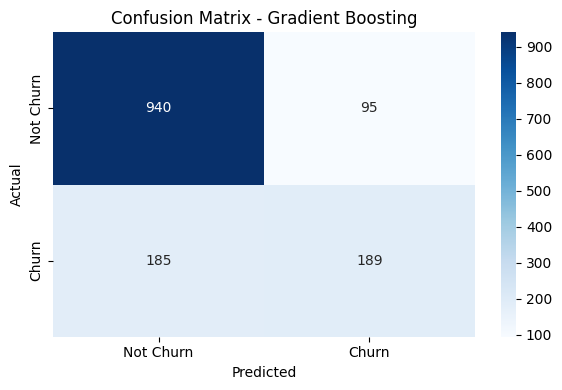

Confusion Matrix Done!


In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
print("=== Gradient Boosting Report ===")
print(classification_report(
    y_test,
    gb.predict(X_test),
    target_names=['Not Churn', 'Churn']
))

cm = confusion_matrix(y_test, gb.predict(X_test))
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Not Churn','Churn'],
            yticklabels=['Not Churn','Churn'],
            cmap='Blues')
plt.title("Confusion Matrix - Gradient Boosting")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("Confusion Matrix Done!")

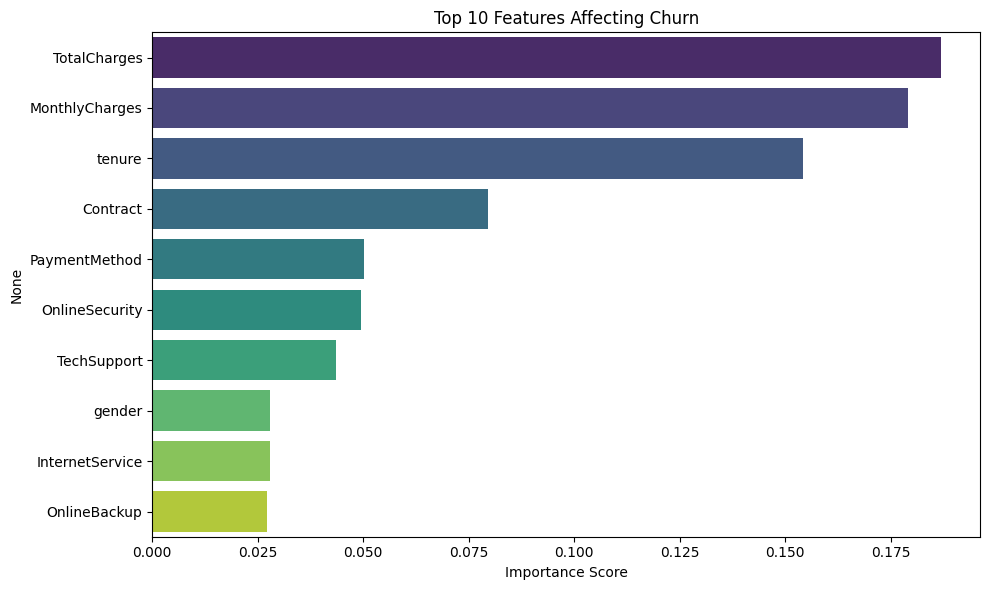

 Feature Importance Done!


In [18]:
import numpy as np

feature_names = df.drop('Churn', axis=1).columns
importances = rf.feature_importances_

indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10,6))
sns.barplot(
    x=importances[indices],
    y=feature_names[indices],
    hue=feature_names[indices],
    palette='viridis',
    legend=False
)
plt.title("Top 10 Features Affecting Churn")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print(" Feature Importance Done!")

In [20]:
def predict_churn(customer_data):
    customer_scaled = scaler.transform([customer_data])
    prediction = gb.predict(customer_scaled)
    probability = gb.predict_proba(customer_scaled)

    if prediction[0] == 1:
        confidence = round(probability[0][1] * 100, 2)
        return f"Customer WILL CHURN! (Confidence: {confidence}%)"
    else:
        confidence = round(probability[0][0] * 100, 2)
        return f"Customer will STAY (Confidence: {confidence}%)"
churn_sample = df[df['Churn']==1].drop(
    'Churn', axis=1).iloc[0].tolist()
stay_sample = df[df['Churn']==0].drop(
    'Churn', axis=1).iloc[0].tolist()

print("Test 1 (Churn Customer):")
print(predict_churn(churn_sample))

print("\nTest 2 (Staying Customer):")
print(predict_churn(stay_sample))

Test 1 (Churn Customer):
Customer will STAY (Confidence: 69.71%)

Test 2 (Staying Customer):
Customer WILL CHURN! (Confidence: 56.39%)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
